# 2002 AA29

## Initialize

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astroquery.jplhorizons import Horizons
import warnings 
from erfa import ErfaWarning

warnings.filterwarnings('ignore', category=ErfaWarning, message='.*dubious year.*')

In [3]:
AU_TO_KM = 1.495978707e8
EARTH_RADIUS_KM = 6371.0
DAYS_PER_JULIAN_YEAR = 365.25

# primary body (sun)
NAME_PRIMARY = 'Sun'
MU_PRIMARY = 1.32712440018e11
COLOR_PRIMARY = 'darkorange'

# secondary body (earth)
NAME_SECONDARY = 'Earth'
MU_SECONDARY = 3.986004418e5
COLOR_SECONDARY = 'dodgerblue'

MU = MU_SECONDARY / (MU_PRIMARY + MU_SECONDARY)

# particle (2002 AA29)
NAME_PARTICLE = '2002 AA$_{29}$'
COLOR_PARTICLE = 'lightseagreen'

# 2026 to 2750
EPOCH_START_JD = 2461041.5
EPOCH_END_JD = 2725476.5
DURATION_DAYS = EPOCH_END_JD - EPOCH_START_JD

# scale factor
K = 2 * np.pi / DAYS_PER_JULIAN_YEAR

In [12]:
def get_rotation_coords(vec_particle, vec_secondary):
    theta = np.arctan2(vec_secondary['y'], vec_secondary['x'])
    omega = (vec_secondary['x'] * vec_secondary['vy'] - vec_secondary['y'] * vec_secondary['vx']) \
            / (vec_secondary['x']**2 + vec_secondary['y']**2)

    dx = vec_particle['x'] - vec_secondary['x']
    dy = vec_particle['y'] - vec_secondary['y']
    dz = vec_particle['z'] - vec_secondary['z']
    
    dvx = vec_particle['vx'] - vec_secondary['vx']
    dvy = vec_particle['vy'] - vec_secondary['vy']
    dvz = vec_particle['vz'] - vec_secondary['vz']
    
    x_rot = dx * np.cos(theta) + dy * np.sin(theta)
    y_rot = -dx * np.sin(theta) + dy * np.cos(theta)
    z_rot = dz
    
    vx_rot = (dvx * np.cos(theta) + dvy * np.sin(theta)) + (omega * y_rot)
    vy_rot = (-dvx * np.sin(theta) + dvy * np.cos(theta)) - (omega * x_rot)
    vz_rot = dvz
    
    return pd.DataFrame({
        'x': x_rot, 'y': y_rot, 'z': z_rot,
        'vx': vx_rot, 'vy': vy_rot, 'vz': vz_rot
    })

def get_jacobi_constant(vec_particle, vec_secondary):
    x, y, z = vec_particle['x'], vec_particle['y'], vec_particle['z']
    vx, vy, vz = vec_particle['vx'], vec_particle['vy'], vec_particle['vz']
    x_s, y_s, z_s = vec_secondary['x'], vec_secondary['y'], vec_secondary['z']
    
    r1 = np.sqrt(x**2 + y**2 + z**2)
    r2 = np.sqrt((x - x_s)**2 + (y - y_s)**2 + (z - z_s)**2)
    
    potential_term = (1 - MU) / r1 + MU / r2
    centrifugal_term = (x * vy - y * vx) / K
    velocity_term = (vx**2 + vy**2 + vz**2) / K**2

    cj = 2 * potential_term + 2 * centrifugal_term - velocity_term
    
    return cj

def get_iso_date(t_days):
    jd = np.array(t_days)
    t = Time(jd, format='jd').iso[:10]
    return t

In [5]:
# Mercury6 data
col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'a', 'e', 'i', 'g', 'n', 'M']

vec_earth = pd.read_csv('EARTH.aei', sep=r'\s+', skiprows=4, names=col)
vec_aa29 = pd.read_csv('2002AA29.aei', sep=r'\s+', skiprows=4, names=col)

x_earth, y_earth, z_earth = vec_earth['x'], vec_earth['y'], vec_earth['z']
x_icrf, y_icrf, z_icrf = vec_aa29['x'], vec_aa29['y'], vec_aa29['z']

vec_aa29_rot = get_rotation_coords(vec_aa29, vec_earth)
x_rot, y_rot, z_rot = vec_aa29_rot['x'], vec_aa29_rot['y'], vec_aa29_rot['z']

In [16]:
# Horizons Data
duration_years = 100
stop_jd = EPOCH_START_JD + (duration_years * DAYS_PER_JULIAN_YEAR)

start_iso = Time(EPOCH_START_JD, format='jd').to_value('iso', subfmt='date')
stop_iso = Time(stop_jd, format='jd').to_value('iso', subfmt='date')

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '200d'
}

obj_earth_hor = Horizons(id='3', location='@sun', epochs=epochs)
vec_earth_hor = obj_earth_hor.vectors()

obj_aa29_hor = Horizons(id='2002 AA29', location='@sun', epochs=epochs)
vec_aa29_hor = obj_aa29_hor.vectors()
vec_aa29_hor_rot = get_rotation_coords(vec_aa29_hor, vec_earth_hor)
x_rot_hor, y_rot_hor, z_rot_hor = vec_aa29_hor_rot['x'], vec_aa29_hor_rot['y'], vec_aa29_hor_rot['z']

## ICRF

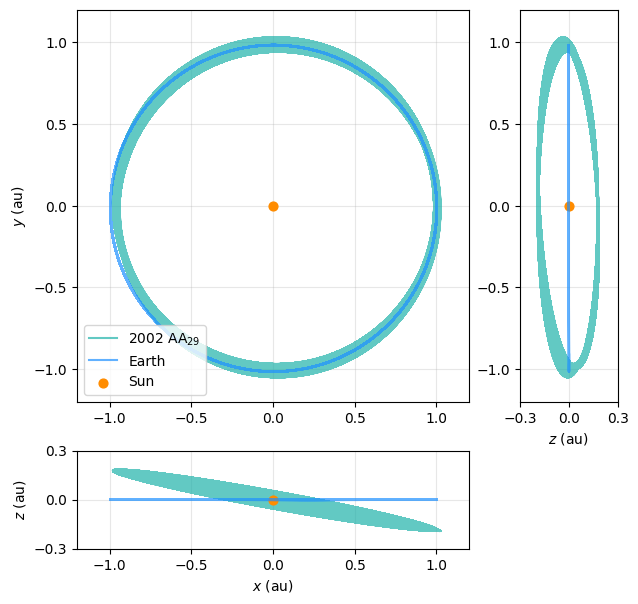

In [37]:
fig = plt.figure(figsize=(7, 7))
gs = fig.add_gridspec(2, 2, 
                      width_ratios=[4, 1], 
                      height_ratios=[4, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[0, 1], sharey=ax1)

ax1.set_aspect('equal')
ax1.plot(x_icrf, y_icrf, label=NAME_PARTICLE, color=COLOR_PARTICLE, alpha=0.7, zorder=2)
ax1.plot(x_earth, y_earth, label=NAME_SECONDARY, color=COLOR_SECONDARY, alpha=0.7, zorder=3)
ax1.scatter(0, 0, label=NAME_PRIMARY, color=COLOR_PRIMARY, s=40, zorder=2)

ax1.set_xlim(-1.2, 1.2)
ax1.set_ylim(-1.2, 1.2)
ax1.set_ylabel('$y$ (au)')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left')

ax2.set_aspect('equal')
ax2.plot(x_icrf, z_icrf, label=NAME_PARTICLE, color=COLOR_PARTICLE, alpha=0.7, zorder=2)
ax2.plot(x_earth, z_earth, label=NAME_SECONDARY, color=COLOR_SECONDARY, alpha=0.7, zorder=3)
ax2.scatter(0, 0, label=NAME_PRIMARY, color=COLOR_PRIMARY, s=40, zorder=2)

ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-0.3, 0.3)
ax2.set_xlabel('$x$ (au)')
ax2.set_ylabel('$z$ (au)')
ax2.set_yticks([-0.3, 0, 0.3])
ax2.grid(alpha=0.3)

ax3.set_aspect('equal')
ax3.plot(z_icrf, y_icrf, label=NAME_PARTICLE, color=COLOR_PARTICLE, alpha=0.7, zorder=2)
ax3.plot(z_earth, y_earth, label=NAME_SECONDARY, color=COLOR_SECONDARY, alpha=0.7, zorder=3)
ax3.scatter(0, 0, label=NAME_PRIMARY, color=COLOR_PRIMARY, s=40, zorder=2)

ax3.set_xlim(-0.3, 0.3)
ax3.set_xticks([-0.3, 0, 0.3])
ax3.set_ylim(-1.2, 1.2)
ax3.set_xlabel('$z$ (au)')
ax3.grid(alpha=0.3)

fig.align_ylabels()
fig.savefig(
    "aa29_orbit.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

## Earth-centric Rotational Coordinates

### Jacobi Constant

/tmp/ipykernel_38966/920946392.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  phi_plot[1:][jump] = np.nan


2.965339688942904
2.962900283446867


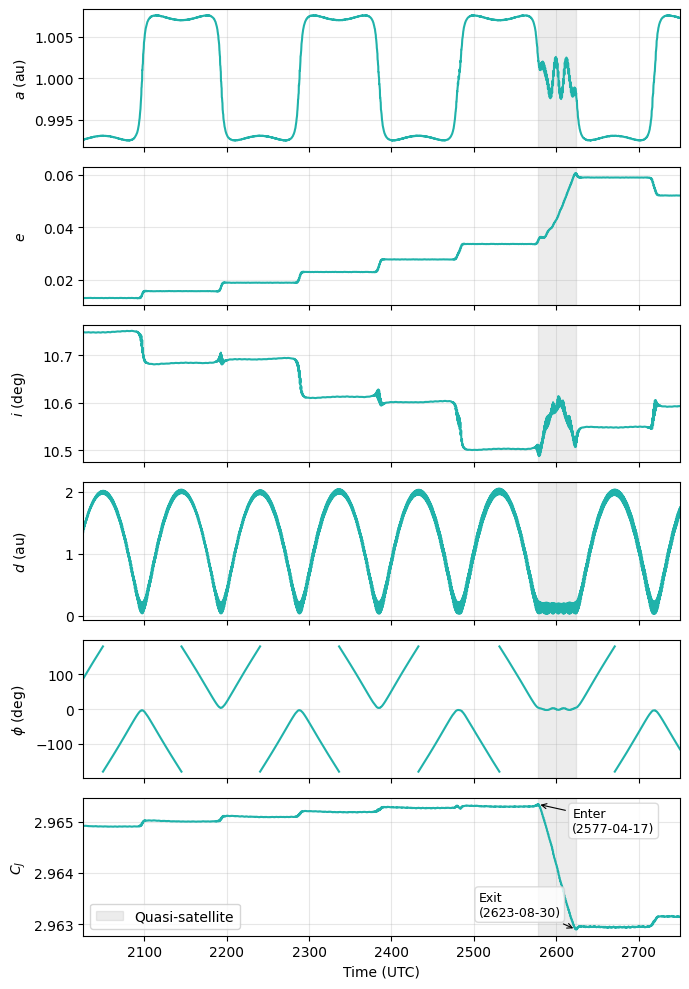

In [38]:
# Distance and Jacobi Const.
dist = np.sqrt(x_rot**2 + y_rot**2 + z_rot**2)
cj = get_jacobi_constant(vec_aa29, vec_earth)

# Phi
lambda_earth = (vec_earth["M"] + vec_earth["g"] + vec_earth["n"]) % 360
lambda_aa29 = (vec_aa29["M"] + vec_aa29["g"]+ vec_aa29["n"]) % 360
phi = (lambda_aa29 - lambda_earth + 180) % 360 - 180
phi_plot = phi.astype(float).copy()
jump = np.abs(np.diff(phi_plot)) > 180
phi_plot[1:][jump] = np.nan


# Capture and Release Point
idx_capture = np.argmax(cj)
idx_release = np.argmin(cj)

t_capture = vec_aa29['time'][idx_capture]
t_release = vec_aa29['time'][idx_release]
capture_duration = t_release - t_capture

mask_pre_capture  = vec_aa29['time'] < t_capture
mask_post_release = vec_aa29['time'] > t_release

# Cj before/after capture
cj_max = np.max(cj)
cj_min = np.min(cj)
cj_mean_pre  = np.mean(cj[mask_pre_capture])
cj_mean_post = np.mean(cj[mask_post_release])

print(cj_max)
print(cj_min)

# JD to Year
time_jd = vec_aa29['time'].values
time_dt = Time(time_jd, format='jd').to_datetime()

dt_capture = time_dt[idx_capture]
dt_release = time_dt[idx_release]
dt_start = time_dt[0]
dt_end = time_dt[-1]

# Plotting
span_style = dict(label='Quasi-satellite', color='gray', alpha=0.15, zorder=0)
annotate_style = dict(
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3', edgecolor='lightgray'),
    fontsize=9, zorder=5
)

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(7, 10), sharex=True)

# a, e, i
ax1.plot(time_dt, vec_aa29['a'], color=COLOR_PARTICLE)
ax1.axvspan(dt_capture, dt_release, **span_style)
ax1.set_ylabel('$a$ (au)')
ax1.grid(alpha=0.3)

ax2.plot(time_dt, vec_aa29['e'], color=COLOR_PARTICLE)
ax2.axvspan(dt_capture, dt_release, **span_style)
ax2.set_ylabel('$e$')
ax2.grid(alpha=0.3)

ax3.plot(time_dt, vec_aa29['i'], color=COLOR_PARTICLE)
ax3.axvspan(dt_capture, dt_release, **span_style)
ax3.grid(alpha=0.3)
ax3.set_ylabel('$i$ (deg)')

# Distance
ax4.plot(time_dt, dist, color=COLOR_PARTICLE)
ax4.axvspan(dt_capture, dt_release, **span_style)
ax4.grid(alpha=0.3)
ax4.set_ylabel('$d$ (au)')

ax5.plot(time_dt, phi_plot, color=COLOR_PARTICLE)
ax5.axvspan(dt_capture, dt_release, **span_style)
ax5.grid(alpha=0.3)
ax5.set_ylabel('$\phi$ (deg)')

# Jacobi const.
ax6.plot(time_dt, cj, color=COLOR_PARTICLE)
ax6.axvspan(dt_capture, dt_release, **span_style)

ax6.annotate(f'Enter\n({get_iso_date(t_capture)})', xy=(dt_capture, cj_max), xytext=(25, -20), **annotate_style)
ax6.annotate(f'Exit\n({get_iso_date(t_release)})', xy=(dt_release, cj_min), xytext=(-70, 10), **annotate_style)

ax6.set_xlim(dt_start, dt_end)
ax6.set_xlabel('Time (UTC)')
ax6.set_ylabel('$C_J$')
ax6.grid(alpha=0.3)
ax6.legend(loc='lower left')

fig.align_ylabels()

plt.tight_layout()

fig.align_ylabels()
fig.savefig(
    "aa29_parameters.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

In [16]:
windows_yr = [
    (0, 100), (100, 200), (200, 300), 
    (300, 400), (400, 500), (500, 600)
]

peak_days = []

for start_yr, end_yr in windows_yr:
    mask = (vec_aa29['time'] >= start_yr * DAYS_PER_JULIAN_YEAR) & (vec_aa29['time'] <= end_yr * DAYS_PER_JULIAN_YEAR)
    window_dist = dist[mask]
    
    if not window_dist.empty:
        idx_max = window_dist.idxmax()
        peak_days.append(vec_aa29.loc[idx_max, 'time'])

peak_iso = get_iso_date(peak_days)
mean_period = np.mean(np.diff(peak_days) / DAYS_PER_JULIAN_YEAR)

print(f"Detected Peak Years: {peak_iso}")
print(f"Average Period: {mean_period:.4f} Years")

Detected Peak Years: []
Average Period: nan Years


/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Relative Trajactory

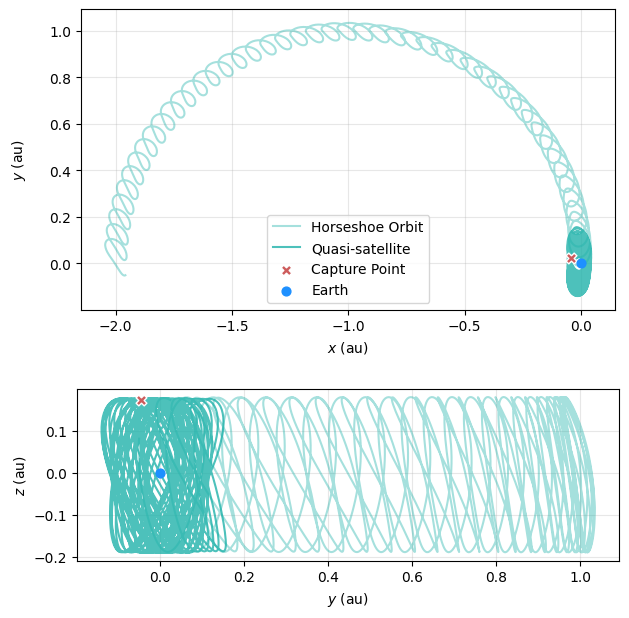

In [39]:
# Orbital Phase Analysis
t_start = t_capture - capture_duration
mask_before = (vec_aa29['time'] >= t_start) & (vec_aa29['time'] <= t_capture)
mask_after = (vec_aa29['time'] >= t_capture) & (vec_aa29['time'] <= t_release)

t_start_iso = get_iso_date(t_start)
t_capture_iso = get_iso_date(t_capture)
t_release_iso = get_iso_date(t_release)

x_capture = x_rot[idx_capture]
y_capture = y_rot[idx_capture]
z_capture = z_rot[idx_capture]

# Rotational Coordinates Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'hspace': 0.05})

ax1.plot(x_rot[mask_before], y_rot[mask_before],
         label=f'Horseshoe Orbit', color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax1.plot(x_rot[mask_after], y_rot[mask_after],
         label=f'Quasi-satellite', color=COLOR_PARTICLE, alpha=0.8, zorder=3)
ax1.scatter(x_capture, y_capture, label='Capture Point', color='indianred', marker='X', s=60, zorder=4, edgecolors='white')
ax1.scatter(0, 0, label=NAME_SECONDARY, color=COLOR_SECONDARY, s=40, zorder=4)

ax1.set_aspect('equal')
ax1.set_xlabel('$x$ (au)')
ax1.set_ylabel('$y$ (au)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(y_rot[mask_before], z_rot[mask_before], color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax2.plot(y_rot[mask_after], z_rot[mask_after], color=COLOR_PARTICLE, alpha=0.8, zorder=3)
ax2.scatter(x_capture, z_capture, color='indianred', marker='X', s=60, zorder=4, edgecolors='white')
ax2.scatter(0, 0, color=COLOR_SECONDARY, s=40, zorder=4)

ax2.set_xlabel('$y$ (au)')
ax2.set_ylabel('$z$ (au)')
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)

fig.align_ylabels()

fig.align_ylabels()
fig.savefig(
    "aa29_horseshoe.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## Horizons Data Comparison

In [ ]:
mask_hor = (vec_aa29['time'] >= 0) & (vec_aa29['time'] <= 100 * DAYS_PER_JULIAN_YEAR)

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.plot(x_rot[mask_hor], y_rot[mask_hor], label=f"{NAME_PARTICLE} (Simulated)", color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax.scatter(x_rot_hor, y_rot_hor, label=f"{NAME_PARTICLE} (Horizons)", color=COLOR_PARTICLE, marker='+', s=30, zorder=3)

ax.scatter(0, 0, label=NAME_SECONDARY, color=COLOR_SECONDARY, s=40, zorder=3)

ax.set_aspect('equal')
ax.set_xlabel('$x$ (au)')
ax.set_ylabel('$y$ (au)')
ax.legend()
ax.grid(True, linestyle=':')

fig.savefig('2002AA29_hor.pdf', format='pdf', bbox_inches='tight')
plt.show()